In [53]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [54]:
x = np.random.randint(-40,40,size=(1000,2))
y = np.reshape([i[0]*3+i[1]*4 for i in x],shape=(-1,1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [55]:
model = Sequential([
    
    Dense(100, activation='sigmoid', input_shape=(2,)),
    Dense(1, activation='linear'),
])

# Compilação
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

# Resumo
model.summary()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Treinamento
model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 13056.5176 - mae: 94.1075 - val_loss: 10957.9404 - val_mae: 87.4914
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12857.0576 - mae: 93.2942 - val_loss: 10782.2520 - val_mae: 86.7158
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12659.1328 - mae: 92.4643 - val_loss: 10601.4746 - val_mae: 85.9123
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 12455.6729 - mae: 91.6096 - val_loss: 10418.7480 - val_mae: 85.0914
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 12250.5322 - mae: 90.7278 - val_loss: 10237.7393 - val_mae: 84.2495
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12049.3721 - mae: 89.8274 - val_loss: 10052.7715 - val_mae: 83.3605
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11846.9365 - mae: 88.8861 - val_loss: 9863.9014 - val_mae: 82.4235
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 11641.5527 - mae: 87.8997 - val_loss: 9672.0879 - v

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


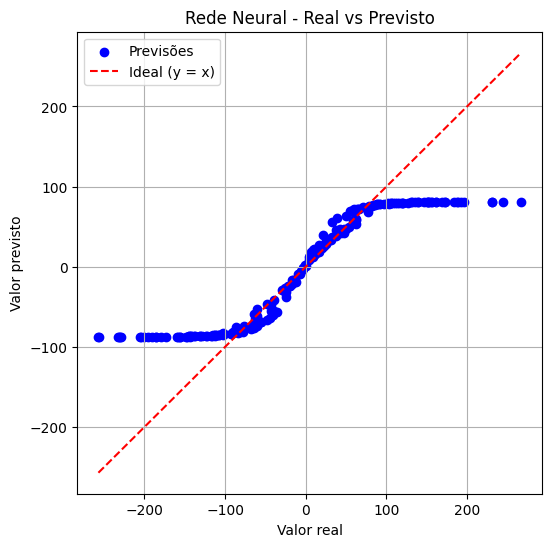

In [57]:
y_pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='blue', label='Previsões')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    label='Ideal (y = x)'
)

plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title("Rede Neural - Real vs Previsto")
plt.legend()
plt.grid()

plt.show()

In [58]:

model.predict(np.array([[1, 0.5]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[15.223732]], dtype=float32)

In [59]:
import numpy as np

weights = model.weights


# =====================================================
# FLOAT -> Q16.16
# =====================================================

FRAC = 16
SCALE = 1 << FRAC  # 65536

INT32_MAX = 2**31 - 1
INT32_MIN = -(2**31)


def float_to_q16_16(value):
    """
    Converte float -> inteiro Q16.16

    Ex:
    1.0   -> 65536
    0.5   -> 32768
    -2.25 -> -147456
    """

    # NaN
    if np.isnan(value):
        return 0

    # +inf
    if np.isposinf(value):
        return INT32_MAX

    # -inf
    if np.isneginf(value):
        return INT32_MIN

    # conversão principal
    fixed = int(np.round(float(value) * SCALE))

    # saturação int32
    fixed = max(INT32_MIN, min(INT32_MAX, fixed))

    return fixed


def to_verilog_q16_16(val):
    """
    Formata para:

    32'sd65536
    -32'sd12345

    compatível com:
    logic signed [31:0]
    """

    fixed = float_to_q16_16(val)

    if fixed < 0:
        return f"-32'sd{abs(fixed)}"
    else:
        return f"32'sd{fixed}"


# =====================================================
# EXPORTAÇÃO
# =====================================================

with open("pesos_q16_16.txt", "w") as f:

    camada_idx = 1

    for var in weights:
        name = var.name
        data = var.numpy()

        tipo_raw = name.lower()

        if "kernel" in tipo_raw:
            tipo = "KERNEL"

        elif "bias" in tipo_raw:
            tipo = "BIAS"

        else:
            tipo = "UNKNOWN"

        # =================================================
        # KERNEL
        # =================================================

        if tipo == "KERNEL":

            # keras: (inputs, neurons)
            # verilog: [neuron][input]
            matriz = data.T

            n_neuronios, n_inputs = matriz.shape

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - PESOS\n")
            f.write(f"        // SHAPE ORIGINAL KERAS: {data.shape}\n")
            f.write("        // reorganizado para [neurônio][entrada]\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for neuronio in range(n_neuronios):

                f.write(f"        // neurônio {neuronio}\n")

                for entrada in range(n_inputs):

                    val = matriz[neuronio][entrada]
                    val_str = to_verilog_q16_16(val)

                    f.write(
                        f"        w{camada_idx}[{neuronio}][{entrada}] = {val_str};\n"
                    )

                f.write("\n")

        # =================================================
        # BIAS
        # =================================================

        elif tipo == "BIAS":

            f.write("        // =====================================================\n")
            f.write(f"        // CAMADA {camada_idx} - BIAS\n")
            f.write("        // formato: Q16.16 fixed-point\n")
            f.write("        // =====================================================\n\n")

            for i, v in enumerate(data):

                val_str = to_verilog_q16_16(v)

                f.write(
                    f"        b{camada_idx}[{i}] = {val_str};\n"
                )

            f.write("\n")

            # kernel + bias = mesma camada
            camada_idx += 1

print("Arquivo salvo: pesos_q16_16.txt")

Arquivo salvo: pesos_q16_16.txt


In [60]:
weights[0].value

<tf.Variable 'sequential_4/dense_8/kernel:0' shape=(2, 100) dtype=float32, numpy=
array([[ 0.12404303,  0.08397589, -0.12992333, -0.08392628, -0.11138692,
        -0.10986904, -0.12301448,  0.11435211,  0.09076162,  0.36489367,
        -0.22460736,  0.12359962,  0.11313935,  0.11870116, -0.10967883,
        -0.17294472,  0.12819152,  0.11661519, -0.11564788, -0.42087832,
        -0.12564266, -0.12710592, -0.10447292, -0.11471158, -0.11034011,
        -0.10042537, -0.11679036,  0.12821807, -0.28716683,  0.08777442,
         0.12755746,  0.11532261, -0.12883018,  0.08891005, -0.3100161 ,
         0.08601515, -0.11451964, -0.11943185, -0.2955398 ,  0.11808641,
        -0.3312812 ,  0.11563946,  0.30560422,  0.11265264, -0.26829255,
        -0.09965158,  0.11579919, -0.11802898, -0.11740424,  0.10690209,
         0.09716433,  0.10100683, -0.10208462, -0.11584092, -0.10041859,
         0.14234409,  0.12740092, -0.11876407, -0.39592782, -0.11758601,
         0.11614414, -0.11531191, -0.11708

In [61]:
import numpy as np

In [62]:
def sigmoide(x):
    return 1/(1+np.exp(-x))

In [63]:
x = np.arange(-10,10.1,0.1)
y = sigmoide(x)

In [64]:
x

array([-1.00000000e+01, -9.90000000e+00, -9.80000000e+00, -9.70000000e+00,
       -9.60000000e+00, -9.50000000e+00, -9.40000000e+00, -9.30000000e+00,
       -9.20000000e+00, -9.10000000e+00, -9.00000000e+00, -8.90000000e+00,
       -8.80000000e+00, -8.70000000e+00, -8.60000000e+00, -8.50000000e+00,
       -8.40000000e+00, -8.30000000e+00, -8.20000000e+00, -8.10000000e+00,
       -8.00000000e+00, -7.90000000e+00, -7.80000000e+00, -7.70000000e+00,
       -7.60000000e+00, -7.50000000e+00, -7.40000000e+00, -7.30000000e+00,
       -7.20000000e+00, -7.10000000e+00, -7.00000000e+00, -6.90000000e+00,
       -6.80000000e+00, -6.70000000e+00, -6.60000000e+00, -6.50000000e+00,
       -6.40000000e+00, -6.30000000e+00, -6.20000000e+00, -6.10000000e+00,
       -6.00000000e+00, -5.90000000e+00, -5.80000000e+00, -5.70000000e+00,
       -5.60000000e+00, -5.50000000e+00, -5.40000000e+00, -5.30000000e+00,
       -5.20000000e+00, -5.10000000e+00, -5.00000000e+00, -4.90000000e+00,
       -4.80000000e+00, -

In [65]:
y

array([4.53978687e-05, 5.01721647e-05, 5.54485247e-05, 6.12797396e-05,
       6.77241496e-05, 7.48462275e-05, 8.27172229e-05, 9.14158739e-05,
       1.01029194e-04, 1.11653341e-04, 1.23394576e-04, 1.36370327e-04,
       1.50710358e-04, 1.66558065e-04, 1.84071905e-04, 2.03426978e-04,
       2.24816770e-04, 2.48455082e-04, 2.74578156e-04, 3.03447030e-04,
       3.35350130e-04, 3.70606141e-04, 4.09567165e-04, 4.52622223e-04,
       5.00201107e-04, 5.52778637e-04, 6.10879359e-04, 6.75082731e-04,
       7.46028834e-04, 8.24424686e-04, 9.11051194e-04, 1.00677082e-03,
       1.11253603e-03, 1.22939862e-03, 1.35851995e-03, 1.50118226e-03,
       1.65880108e-03, 1.83293894e-03, 2.02532039e-03, 2.23784852e-03,
       2.47262316e-03, 2.73196076e-03, 3.01841632e-03, 3.33480731e-03,
       3.68423990e-03, 4.07013772e-03, 4.49627316e-03, 4.96680165e-03,
       5.48629890e-03, 6.05980149e-03, 6.69285092e-03, 7.39154134e-03,
       8.16257115e-03, 9.01329865e-03, 9.95180187e-03, 1.09869426e-02,
      